In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import json
from pathlib import Path

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from utils.tools import aggregate_results

In [3]:
def get_suite(row):

    n_demos = row["number of demonstrations"]
    type_demos = row["type of demonstrations"][0:3]
    instr = "impl" if row["use instructions"] == "no" else "expl"

    return f"{n_demos}-{type_demos}-{instr}"

def suite_key(s):
    parts = s.split('-')
    return (parts[0], parts[2], parts[1])

def capitalize(s):
    return s[0].upper() + s[1:]

def order_suites(strings):
    return sorted(strings, key=lambda s: (
        s.split('-')[2],
        s.split('-')[0],
        s.split('-')[1],
    ))

def order_models(strings):
    return sorted(strings, key=lambda s: (
        int(s.split('-')[1][:-1]),  # Param count, B dropped
        #s.split('-')[0],  # Model name
    ), reverse=True)

def bold_extreme_values(s, by_model=True):
    # Bold max for mean

    if not by_model:
        is_max = s == s.max()
        return ['font-weight: bold' if v else '' for v in is_max]
    
    font_array = []

    model_level = s.index.names.index('Model')
    models = s.index.get_level_values(model_level)
    models = pd.Series(list(models)).unique()

    idx = pd.IndexSlice
    
    for model in models:   
        values_by_model = s.loc[idx[model]]
        is_max = values_by_model == values_by_model.max()
        font_array += ['font-weight: bold' if v else '' for v in is_max]

    return font_array

In [4]:
def heatmap(df, metric_cols):
    fig, axes = plt.subplots(len(metric_cols), 1, figsize=(10, 15), sharex=True, sharey=True)

    for i, ax in enumerate(axes):

        label, metric, *_ = metric_cols[i].split(" ")

        pivoted = df.pivot(index='model', columns='suite', values=metric_cols[i])
        pivoted = pivoted.reindex(order_suites(pivoted.columns), axis=1)
        pivoted = pivoted.reindex(order_models(pivoted.index), axis=0)
        
        ax.set_title(capitalize(label))
        
        sns.heatmap(
            pivoted,
            fmt=".2g",
            annot=True,
            square=True,
            cmap="Blues",
            ax=ax,
            cbar=False
        )

        if i == 2:
            # Rotate xticks
            ax.set_xticklabels(ax.get_xticklabels(), rotation=40)

    mappable = ax.get_children()[0]
    plt.colorbar(mappable, ax=axes, orientation = 'vertical')

    return fig, ax

In [5]:
def my_heatmap(df, metric_cols):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

    plot_ax = [axes[0, 0], axes[0, 1], axes[1, 0]]

    for i, ax in enumerate(plot_ax):

        label, metric, *_ = metric_cols[i].split(" ")

        pivoted = df.pivot(index='model', columns='suite', values=metric_cols[i])
        pivoted = pivoted.reindex(order_suites(pivoted.columns), axis=1)
        pivoted = pivoted.reindex(order_models(pivoted.index), axis=0)
        
        ax.set_title(capitalize(label))
        
        sns.heatmap(
            pivoted,
            fmt=".2g",
            annot=True,
            square=True,
            cmap="Blues",
            ax=ax,
            cbar=False
        )

        if i == 2:
            # Rotate xticks
            ax.set_xticklabels(ax.get_xticklabels(), rotation=40)

    # Move plots
    topright = plot_ax[1]
    pos = topright.get_position()
    pos.x0 = pos.x0 - 0.05
    pos.x1 = pos.x1 - 0.05
    topright.set_position(pos)

    bottomleft = plot_ax[2]
    pos = bottomleft.get_position()
    pos.x0 = pos.x0 + 0.185
    pos.x1 = pos.x1 + 0.185
    bottomleft.set_position(pos)

    plt.axis("off")

    mappable = ax.get_children()[0]
    #plt.colorbar(mappable, ax=axes, orientation = 'horizontal')

    return fig, ax

In [6]:
metric_cols_f1 = ["theme f1 mean", "topic f1 mean", "concept f1 mean"]
metric_cols_prec = ["theme precision mean", "topic precision mean", "concept precision mean"]
metric_cols_rec = ["theme recall mean", "topic recall mean", "concept recall mean"]

metric_cols = [metric_cols_f1, metric_cols_prec, metric_cols_rec]

res = pd.read_csv("./data/metrics.csv", sep=";")
res = res.sort_values(by=["use instructions", "number of demonstrations", "type of demonstrations"])
res["suite"] = res.apply(get_suite, axis=1)

,Unnamed: 0,model,number of demonstrations,type of demonstrations,use instructions,total accuracy mean,total accuracy std,total accuracy count,theme accuracy mean,theme accuracy std,...,concept precision mean,concept precision std,concept precision count,concept recall mean,concept recall std,concept recall count,concept f1 mean,concept f1 std,concept f1 count,suite
22,22,Mistral-7B,0,none,yes,0.488598,0.002835,5,0.649346,0.002131,...,1.000000,0.000000,5,0.027636,0.004146,5,0.053761,0.007860,5,0-non-expl
55,55,Qwen3-8B,0,none,yes,0.577196,0.008504,5,0.824299,0.001869,...,1.000000,0.000000,5,0.258182,0.011208,5,0.410304,0.014181,5,0-non-expl
44,44,Qwen3-32B,0,none,yes,0.651589,0.001672,5,0.931215,0.001564,...,0.987467,0.004789,5,0.400000,0.003636,5,0.569350,0.003411,5,0-non-expl
33,33,Mistral-24B,0,none,yes,0.600693,0.021986,5,0.871276,0.014753,...,0.845974,0.020032,5,0.545863,0.048880,5,0.662788,0.040702,5,0-non-expl
11,11,Llama-70B,0,none,yes,0.798131,0.000000,5,0.942056,0.000000,...,0.839721,0.000000,5,0.876364,0.000000,5,0.857651,0.000000,5,0-non-expl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,20,Llama-70B,6,positive,no,0.737094,0.058551,5,0.926973,0.006943,...,0.984099,0.007610,5,0.598226,0.151740,5,0.734654,0.118275,5,6-pos-impl
31,31,Mistral-7B,6,positive,no,0.431385,0.062265,5,0.534267,0.004249,...,0.866040,0.167469,5,0.247352,0.181969,5,0.339319,0.187585,5,6-pos-impl
42,42,Mistral-24B,6,positive,no,0.511385,0.015022,5,0.730843,0.027094,...,1.000000,0.000000,5,0.111560,0.036192,5,0.199209,0.058283,5,6-pos-impl
53,53,Qwen3-32B,6,positive,no,0.630246,0.033353,5,0.810208,0.027152,...,0.995092,0.007584,5,0.460364,0.032788,5,0.629000,0.031693,5,6-pos-impl


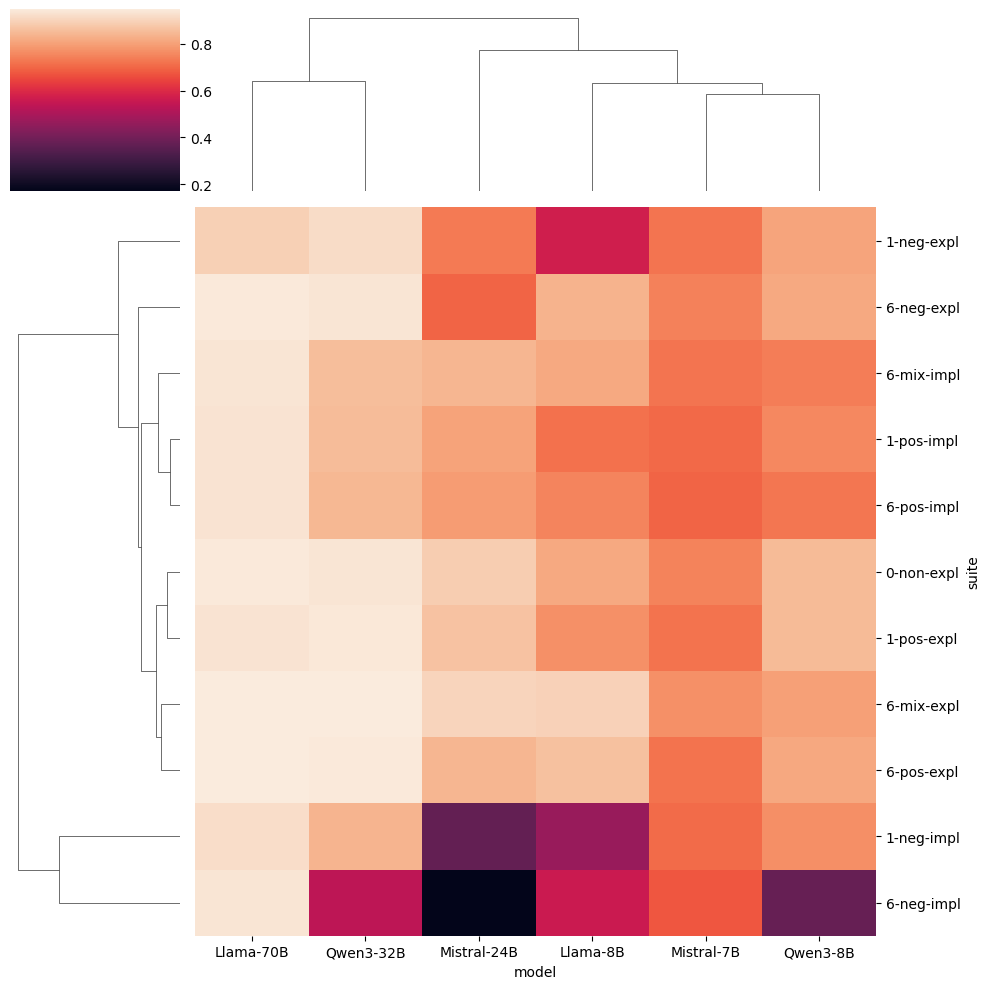

In [12]:
def my_clustermap(df):

    models = np.sort(df["model"].unique())

    metric_cols = [
        "theme f1 mean",
        "theme precision mean",
        "theme recall mean",
        "topic f1 mean",
        "topic precision mean",
        "topic recall mean",
        "concept f1 mean",
        "concept precision mean",
        "concept recall mean"
    ]
   
    # Plots config
    n_cols = 2
    n_models = len(models)

    #fig, axes = plt.subplots(n_models // n_cols, n_cols, figsize=(20, 16), sharex=True, sharey=True)
    

    #ax = axes[i // n_cols, i % n_cols]
    #model = models[i]
    
    #data = df.loc[df["model"] == model, :]
    #data = data.sort_values(by="suite", key=lambda col: col.map(suite_key))

    """
    plot_df = pd.DataFrame({
        'suite': data['suite'].tolist() * 9,
        'metric': (
            ['Theme F1'] * len(data) +
            ['Theme Precision'] * len(data) +
            ['Theme Recall'] * len(data) +
            ['Topic F1'] * len(data) +
            ['Topic Precision'] * len(data) +
            ['Topic Recall'] * len(data) +
            ['Concept F1'] * len(data) +
            ['Concept Precision'] * len(data) +
            ['Concept Recall'] * len(data)
        ),
        'mean': pd.concat([data[col] for col in metric_cols], ignore_index=True)
    })
    """

    pal = {
        "Theme F1": "blue",
        "Theme Precision": "blue",
        "Theme Recall": "blue",
        "Topic F1": "red",
        "Topic Precision": "red",
        "Topic Recall": "red",
        "Concept F1": "green",
        "Concept Precision": "green",
        "Concept Recall": "green",
    }

    das = {
        "Theme F1": "",
        "Theme Precision": (1, 2),
        "Theme Recall": (2, 4),
        "Topic F1": "",
        "Topic Precision": (1, 2),
        "Topic Recall": (2, 4),
        "Concept F1": "",
        "Concept Precision": (1, 2),
        "Concept Recall": (2, 4),
    }

    sns.clustermap(
        df,
        pivot_kws={
            "index": "suite",
            "columns": "model",
            "values": "theme f1 mean"
        }
    )
    
    plt.tight_layout()

my_clustermap(res)